In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

np.random.seed(42)
%matplotlib inline


In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [3]:
import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/drive_dataset")

In [4]:
BASE_PATH = "/content/drive_dataset"

for root, dirs, files in os.walk(BASE_PATH):
    level = root.replace(BASE_PATH, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files)[:5]:
        print(f"{indent}  {f}")
    if len(files) > 5:
        print(f"{indent}  ({len(files)} files total)")


drive_dataset/
  DRIVE/
    training/
      images/
        21_training.tif
        22_training.tif
        23_training.tif
        24_training.tif
        25_training.tif
        (20 files total)
      mask/
        21_training_mask.gif
        22_training_mask.gif
        23_training_mask.gif
        24_training_mask.gif
        25_training_mask.gif
        (20 files total)
      1st_manual/
        21_manual1.gif
        22_manual1.gif
        23_manual1.gif
        24_manual1.gif
        25_manual1.gif
        (20 files total)
    test/
      images/
        01_test.tif
        02_test.tif
        03_test.tif
        04_test.tif
        05_test.tif
        (20 files total)
      mask/
        01_test_mask.gif
        02_test_mask.gif
        03_test_mask.gif
        04_test_mask.gif
        05_test_mask.gif
        (20 files total)


In [5]:
IMAGE_DIR = os.path.join(BASE_PATH, "DRIVE", "training", "images")
VESSEL_MASK_DIR = os.path.join(BASE_PATH, "DRIVE", "training", "1st_manual")

image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.tif")))
vessel_files = sorted(glob.glob(os.path.join(VESSEL_MASK_DIR, "*.gif")))

print("Number of retinal images found :", len(image_files))
print("Number of vessel ground-truth masks found:", len(vessel_files))
print("Example image:", image_files[0] if image_files else "NONE FOUND - check IMAGE_DIR")
print("Example mask :", vessel_files[0] if vessel_files else "NONE FOUND - check VESSEL_MASK_DIR")

Number of retinal images found : 20
Number of vessel ground-truth masks found: 20
Example image: /content/drive_dataset/DRIVE/training/images/21_training.tif
Example mask : /content/drive_dataset/DRIVE/training/1st_manual/21_manual1.gif


In [6]:
def load_retinal_image(path):
    img = Image.open(path).convert("RGB")
    return np.array(img)

def load_vessel_mask(path):
    mask = Image.open(path).convert("L")
    mask = np.array(mask)
    return (mask > 127).astype(np.uint8)


## Step 2: Retinal Image as a Matrix

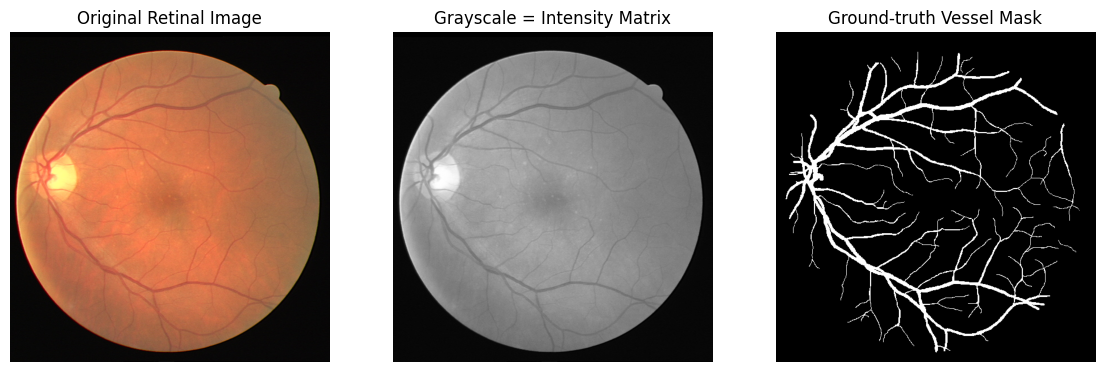

Image matrix shape: (584, 565)

A tiny 5x5 patch of the actual intensity MATRIX:
[[ 74. 129. 176. 188. 191.]
 [138. 180. 188. 186. 184.]
 [177. 191. 186. 178. 172.]
 [190. 183. 176. 172. 164.]
 [188. 177. 167. 162. 160.]]


In [7]:
IDX = 0
rgb_image = load_retinal_image(image_files[IDX])
vessel_mask = load_vessel_mask(vessel_files[IDX])

gray_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY).astype(np.float64)

fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].imshow(rgb_image); axs[0].set_title("Original Retinal Image"); axs[0].axis("off")
axs[1].imshow(gray_image, cmap="gray"); axs[1].set_title("Grayscale = Intensity Matrix"); axs[1].axis("off")
axs[2].imshow(vessel_mask, cmap="gray"); axs[2].set_title("Ground-truth Vessel Mask"); axs[2].axis("off")
plt.show()

print("Image matrix shape:", gray_image.shape)
print("\nA tiny 5x5 patch of the actual intensity MATRIX:")
print(gray_image[100:105, 100:105])


## Step 3: Feature Vectors from Image Patches

In [8]:
PATCH = 16
def extract_patches(gray, mask, patch=PATCH):
    h, w = gray.shape
    patches, mask_patches, coords = [], [], []
    for y in range(0, h - patch, patch):
        for x in range(0, w - patch, patch):
            patches.append(gray[y:y+patch, x:x+patch])
            mask_patches.append(mask[y:y+patch, x:x+patch])
            coords.append((y, x))
    return patches, mask_patches, coords

def patch_to_feature_vector(patch):
    gx = np.diff(patch, axis=1)
    gy = np.diff(patch, axis=0)
    return np.array([
        patch.mean(),
        patch.std(),
        np.abs(gx).mean(),
        np.abs(gy).mean()
    ])

patches, mask_patches, coords = extract_patches(gray_image, vessel_mask)
feature_matrix = np.array([patch_to_feature_vector(p) for p in patches])

print("Number of patches:", len(patches))
print("Feature matrix shape (patches x features):", feature_matrix.shape)
print("Example feature vector (patch 0):", feature_matrix[0])


Number of patches: 1260
Feature matrix shape (patches x features): (1260, 4)
Example feature vector (patch 0): [3.296875   3.65474729 0.26666667 0.93333333]


## Step 4: Dot Product

In [9]:
v1 = feature_matrix[0]
v2 = feature_matrix[1]
dot_value = np.dot(v1, v2)

print("Feature vector of patch 0:", v1)
print("Feature vector of patch 1:", v2)
print("Dot product (v1 . v2):", dot_value)
weights_demo = np.array([0.5, 0.2, 1.0, 1.0])
weighted_sum = np.dot(v1, weights_demo)
print("\nExample weighted sum using dot product (like one neuron):", weighted_sum)


Feature vector of patch 0: [3.296875   3.65474729 0.26666667 0.93333333]
Feature vector of patch 1: [3.28125    3.55412942 0.32083333 1.0125    ]
Dot product (v1 . v2): 24.83787150767625

Example weighted sum using dot product (like one neuron): 3.57938695746953


## Step 5: Eigenvalues & Eigenvectors

To make this analysis meaningful, we gather feature vectors from **patches of several
real retinal images** (not random data) and study the directions in which these
features vary the most using PCA-style eigen-analysis.

In [10]:
N_IMAGES_FOR_PCA = min(5, len(image_files))
all_features = []
all_mask_patches = []

for i in range(N_IMAGES_FOR_PCA):
    g = cv2.cvtColor(load_retinal_image(image_files[i]), cv2.COLOR_RGB2GRAY).astype(np.float64)
    m = load_vessel_mask(vessel_files[i])
    p, mp, c = extract_patches(g, m)
    all_features.extend([patch_to_feature_vector(patch) for patch in p])
    all_mask_patches.extend(mp)

all_features = np.array(all_features)
vessel_ratio_all = np.array([mp.mean() for mp in all_mask_patches])
is_vessel_patch = vessel_ratio_all > 0.2

print("Combined feature matrix from", N_IMAGES_FOR_PCA, "images:", all_features.shape)
print("Vessel-like patches:", is_vessel_patch.sum(), "/", len(is_vessel_patch))


Combined feature matrix from 5 images: (6300, 4)
Vessel-like patches: 1133 / 6300


In [11]:
mean_f = all_features.mean(axis=0)
std_f = all_features.std(axis=0)
standardized = (all_features - mean_f) / (std_f + 1e-8)

cov_matrix = np.cov(standardized, rowvar=False)
print("Covariance matrix (feature x feature):\n", cov_matrix)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("\nEigenvalues (variance explained by each direction):", eigenvalues)
print("\nTop eigenvector (most important feature-combination direction):")
print(eigenvectors[:, 0])


Covariance matrix (feature x feature):
 [[1.00015876 0.01146168 0.21412882 0.25983754]
 [0.01146168 1.00015875 0.8485915  0.80485064]
 [0.21412882 0.8485915  1.00015875 0.60083881]
 [0.25983754 0.80485064 0.60083881 1.00015874]]

Eigenvalues (variance explained by each direction): [2.55578822 0.99673906 0.39743569 0.05067203]

Top eigenvector (most important feature-combination direction):
[0.17369999 0.59255027 0.56035104 0.55201377]


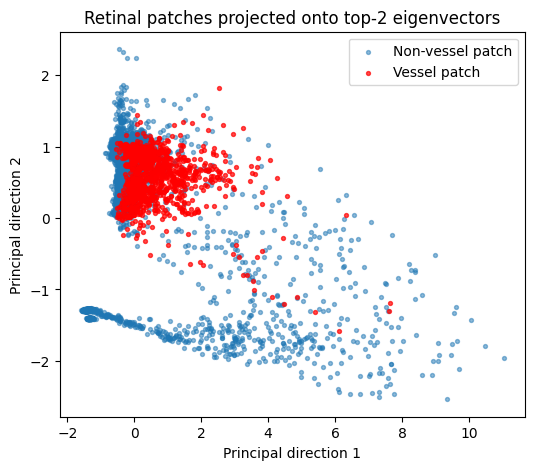

In [12]:
top2 = eigenvectors[:, :2]
projected = standardized @ top2

plt.figure(figsize=(6, 5))
plt.scatter(projected[~is_vessel_patch, 0], projected[~is_vessel_patch, 1],
            s=8, alpha=0.5, label="Non-vessel patch")
plt.scatter(projected[is_vessel_patch, 0], projected[is_vessel_patch, 1],
            s=8, alpha=0.7, color="red", label="Vessel patch")
plt.xlabel("Principal direction 1")
plt.ylabel("Principal direction 2")
plt.title("Retinal patches projected onto top-2 eigenvectors")
plt.legend()
plt.show()


## Step 6: Derivatives on Real Image Intensities

dI/dx shape: (584, 564)  dI/dy shape: (583, 565)


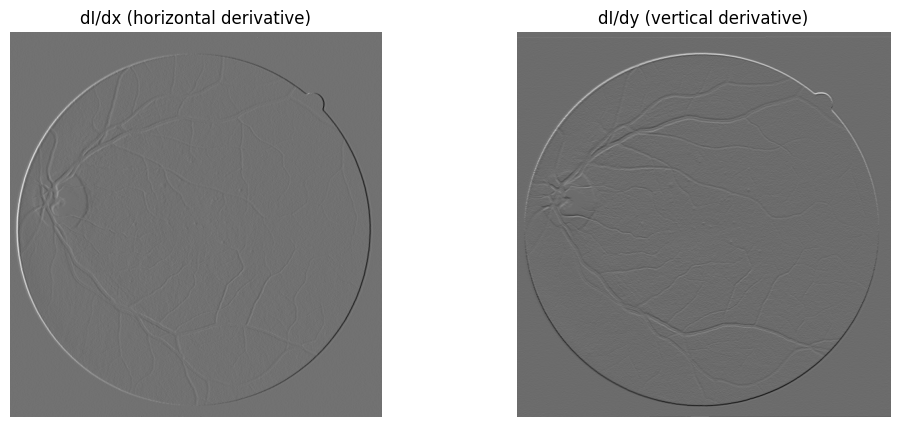

In [13]:
dIdx = np.diff(gray_image, axis=1)
dIdy = np.diff(gray_image, axis=0)

print("dI/dx shape:", dIdx.shape, " dI/dy shape:", dIdy.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(dIdx, cmap="gray"); axs[0].set_title("dI/dx (horizontal derivative)"); axs[0].axis("off")
axs[1].imshow(dIdy, cmap="gray"); axs[1].set_title("dI/dy (vertical derivative)"); axs[1].axis("off")
plt.show()


## Step 7: Gradient-based Vessel Analysis

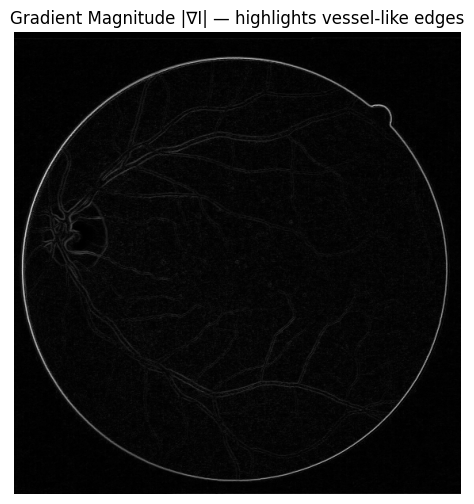

In [14]:
h = min(dIdx.shape[0], dIdy.shape[0])
w = min(dIdx.shape[1], dIdy.shape[1])
dIdx_c = dIdx[:h, :w]
dIdy_c = dIdy[:h, :w]

gradient_magnitude = np.sqrt(dIdx_c**2 + dIdy_c**2)

plt.figure(figsize=(6, 6))
plt.imshow(gradient_magnitude, cmap="gray")
plt.title("Gradient Magnitude |∇I| — highlights vessel-like edges")
plt.axis("off")
plt.show()


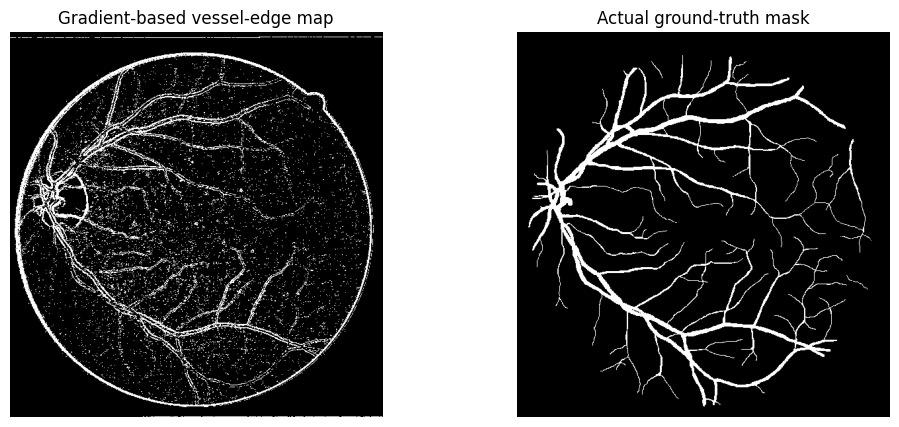

Pixels marked 'edge/vessel-like' by gradient thresholding: 9.71%
Pixels marked as vessel in ground truth               : 7.47%


In [15]:
threshold = np.percentile(gradient_magnitude, 90)
edge_vessel_map = (gradient_magnitude > threshold).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(edge_vessel_map, cmap="gray"); axs[0].set_title("Gradient-based vessel-edge map"); axs[0].axis("off")
axs[1].imshow(vessel_mask[:h, :w], cmap="gray"); axs[1].set_title("Actual ground-truth mask"); axs[1].axis("off")
plt.show()

print(f"Pixels marked 'edge/vessel-like' by gradient thresholding: {edge_vessel_map.mean()*100:.2f}%")
print(f"Pixels marked as vessel in ground truth               : {vessel_mask.mean()*100:.2f}%")


## Step 8: Building a Small Dataset for the Neural Network

Input `X` = feature vector per patch (from Step 3).
Output `y` = 1 if the patch is mostly vessel (from the real ground-truth mask), else 0.

In [16]:
X = feature_matrix.copy()
y = np.array([1.0 if mp.mean() > 0.2 else 0.0 for mp in mask_patches])

X_mean, X_std = X.mean(axis=0), X.std(axis=0)
X_norm = (X - X_mean) / (X_std + 1e-8)

print("Training data shape:", X_norm.shape, " Labels shape:", y.shape)
print("Number of vessel patches:", int(y.sum()), "/", len(y))


Training data shape: (1260, 4)  Labels shape: (1260,)
Number of vessel patches: 173 / 1260


## Step 9: A Very Small Neural Network (Manual, NumPy only)

Architecture: `4 inputs -> 4 hidden neurons (tanh) -> 1 output neuron (sigmoid)`

This is intentionally tiny — the goal is to show how gradients are computed and
weights are updated, not to build a high-performance model.

In [17]:
n_inputs = X_norm.shape[1]
n_hidden = 4
n_output = 1

W1 = np.random.randn(n_inputs, n_hidden) * 0.5
b1 = np.zeros((1, n_hidden))
W2 = np.random.randn(n_hidden, n_output) * 0.5
b2 = np.zeros((1, n_output))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh_derivative(a):
    return 1 - a**2


In [18]:
def forward(X):

    z1 = X @ W1 + b1
    a1 = np.tanh(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1, a1, z2, a2


## Step 10: Chain Rule & Backpropagation (Manual)

In [19]:
def compute_loss(a2, y):
    y = y.reshape(-1, 1)
    eps = 1e-8
    return -np.mean(y * np.log(a2 + eps) + (1 - y) * np.log(1 - a2 + eps))


In [20]:
def backward(X, y, z1, a1, z2, a2):
    m = X.shape[0]
    y = y.reshape(-1, 1)

    dz2 = (a2 - y)
    dW2 = a1.T @ dz2 / m
    db2 = dz2.mean(axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * tanh_derivative(a1)
    dW1 = X.T @ dz1 / m
    db1 = dz1.mean(axis=0, keepdims=True)

    return dW1, db1, dW2, db2


## Step 11: Training the Network (Gradient Descent)

Epoch   0 | Loss: 0.7461
Epoch  50 | Loss: 0.2813
Epoch 100 | Loss: 0.2527
Epoch 150 | Loss: 0.2317
Epoch 200 | Loss: 0.2169
Epoch 250 | Loss: 0.2048


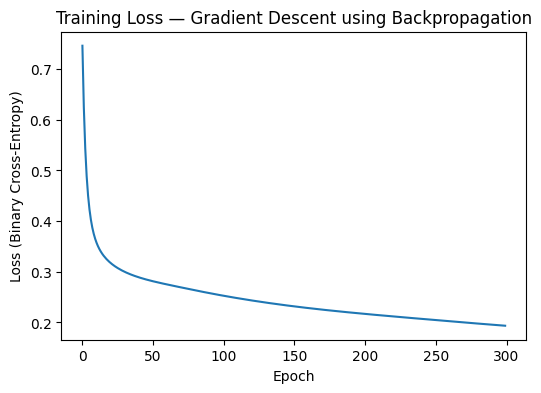

In [21]:
LR = 0.5
EPOCHS = 300
losses = []

for epoch in range(EPOCHS):
    z1, a1, z2, a2 = forward(X_norm)
    loss = compute_loss(a2, y)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward(X_norm, y, z1, a1, z2, a2)

    # Gradient descent update: move weights opposite to the gradient
    W1 -= LR * dW1
    b1 -= LR * db1
    W2 -= LR * dW2
    b2 -= LR * db2

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("Training Loss — Gradient Descent using Backpropagation")
plt.show()


## Step 12: Reconstructing a Vessel Map from the Network's Predictions

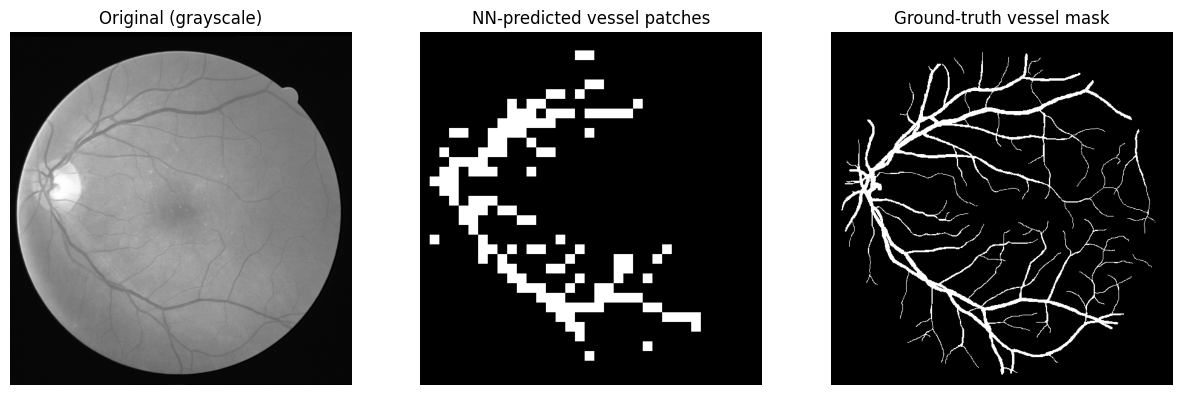

Patch-level accuracy of the tiny NN on this image: 91.35%


In [22]:
_, _, _, final_pred = forward(X_norm)
predicted_labels = (final_pred.flatten() > 0.5).astype(np.uint8)

predicted_map = np.zeros_like(gray_image, dtype=np.uint8)
for (y0, x0), label in zip(coords, predicted_labels):
    predicted_map[y0:y0+PATCH, x0:x0+PATCH] = label

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(gray_image, cmap="gray"); axs[0].set_title("Original (grayscale)"); axs[0].axis("off")
axs[1].imshow(predicted_map, cmap="gray"); axs[1].set_title("NN-predicted vessel patches"); axs[1].axis("off")
axs[2].imshow(vessel_mask, cmap="gray"); axs[2].set_title("Ground-truth vessel mask"); axs[2].axis("off")
plt.show()

accuracy = (predicted_labels == y).mean()
print(f"Patch-level accuracy of the tiny NN on this image: {accuracy*100:.2f}%")


## Step 13: Final Numerical Summary

In [24]:
vessel_area_percent_nn = predicted_map.mean() * 100
vessel_area_percent_truth = vessel_mask.mean() * 100
vessel_area_percent_gradient = edge_vessel_map.mean() * 100

print("=== Final Vessel Analysis Summary ===")
print(f"Image analyzed                     : {os.path.basename(image_files[IDX])}")
print(f"Image size                          : {gray_image.shape}")
print(f"Patches analyzed                    : {len(patches)} (patch size {PATCH}x{PATCH})")
print(f"Vessel area % (ground truth)        : {vessel_area_percent_truth:.2f}%")
print(f"Vessel area % (gradient method)     : {vessel_area_percent_gradient:.2f}%")
print(f"Vessel area % (tiny NN prediction)  : {vessel_area_percent_nn:.2f}%")
print(f"Tiny NN patch-level accuracy        : {accuracy*100:.2f}%")
print(f"Top PCA eigenvalue (dominant feature variance): {eigenvalues[0]:.4f}")


=== Final Vessel Analysis Summary ===
Image analyzed                     : 21_training.tif
Image size                          : (584, 565)
Patches analyzed                    : 1260 (patch size 16x16)
Vessel area % (ground truth)        : 7.47%
Vessel area % (gradient method)     : 9.71%
Vessel area % (tiny NN prediction)  : 10.40%
Tiny NN patch-level accuracy        : 91.35%
Top PCA eigenvalue (dominant feature variance): 2.5558


the main outcome is an automated vessel-region representation that can serve as a foundation for further retinal image analysis